# Practical Application III: Comparing Classifiers (Assignment 17.1)

## Overview
This notebook compares several classification models on a [**marketing campaign dataset**](https://www.kaggle.com/datasets/ahsan81/superstore-marketing-campaign-dataset) to predict whether a customer responds to an offer.

Models compared:
- k-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree
- Support Vector Machine (SVM)

The workflow follows a typical applied ML project:
1) understand the data,
2) prepare features,
3) train/validate multiple models,
4) tune hyperparameters, and
5) summarize findings for nontechnical stakeholders.

### Getting Started
**How to run this notebook**
1. Download a Kaggle marketing campaign dataset:  [**marketing campaign dataset**](https://www.kaggle.com/datasets/ahsan81/superstore-marketing-campaign-dataset).
2. Place the CSV under `data/` (or update `DATA_PATH` below).
3. Run the notebook top-to-bottom.

This notebook is designed to be reproducible: the file path, target column, and random seed are defined near the top.

### Problem 1: Understanding the Data
Before modeling, we confirm:
- the prediction target (binary classification),
- feature types (numeric vs categorical),
- missing values,
- class balance (response rate).

**This matters because class imbalance affects metric selection and how we interpret performance.**

### Problem 2: Read in the Data
Update `DATA_PATH` and `TARGET_COL` for your dataset.

**Recommended pattern:** choose a marketing campaign dataset where the target indicates campaign acceptance/response (0/1).

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, \
 roc_auc_score,ConfusionMatrixDisplay, RocCurveDisplay, classification_report

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# For quick inspection , I create a utility function to recall the structure of the data that accepts any df and prints thetop2 and last 2 data points.
def head_2_tail2(X):
  return X.head(2), X.tail(2)

#### Load the dataset
If your CSV uses a different delimiter or encoding, adjust `read_csv` accordingly.

In [3]:
# Find the Kaggle path
import kagglehub
# Download latest version
path = kagglehub.dataset_download("ahsan81/superstore-marketing-campaign-dataset")
print("Path to dataset files:", path)

100%|██████████| 55.4k/55.4k [00:00<00:00, 12.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ahsan81/superstore-marketing-campaign-dataset/versions/7


In [4]:

DATA_PATH = path+"/superstore_data.csv"   # <-- update
TARGET_COL = "Response"                    # <-- update

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(5)


Shape: (2240, 22)


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,59,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,0,1,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,16,24,11,0,34,2,3,1,2,7,1,0


### Problem 3: Understanding the Features
Marketing campaign datasets commonly include customer demographics and behavior/engagement variables such as:
- demographic: age or year of birth, education, marital status
- household: kids/teens at home
- economic: income
- behavior: recency, spend amounts by category, prior campaign responses, web visits, etc.

Next, we verify data types and identify missingness.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### Missing values
We quantify missingness to decide how to handle it. In this notebook we use **imputation inside pipelines** (leak-safe).

In [6]:
missing_rate_abs = df.isna().sum().sort_values(ascending=False)
missing_rate_mean = df.isna().mean().sort_values(ascending=False)
# Convert into dataframe
missing_df = pd.concat([missing_rate_abs, missing_rate_mean], axis=1, keys=["count", "%"])
missing_df.head()

,count,%
Income,24,0.010714
Id,0,0.000000
Year_Birth,0,0.000000
Education,0,0.000000
Marital_Status,0,0.000000


#### What we observed

During exploratory data analysis (EDA), we quantified missingness by computing the proportion of missing values in each column. This step helps answer two key questions:

#### How much data is missing?

Is missingness widespread or concentrated in a few variables?

In this dataset, missing values appear in a limited number of features and do not dominate the dataset. Since this is a binary classification problem, it is important to have the missing values imputed as a safe strategy.


#### Target distribution (class balance)
Marketing response is often imbalanced. We inspect the response rate to choose evaluation metrics appropriately.

In [7]:
y_counts = df[TARGET_COL].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(df)).rename("proportion"))
# We have an imbalance situation with 85% to the majortity class (Response=0)
# We can think of undersampling , SMOTE or class weights or hyperparameter tuning .

,count
Response,
0,1906
1,334


,proportion
Response,
0,0.850893
1,0.149107


### Problem 4: Understanding the Task
**Business objective:** predict which customers are most likely to respond so the marketing team can prioritize outreach and allocate resources efficiently.

**ML objective:** learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-validation and a held-out test set.

### Problem 5: Engineering Features
We set up a preprocessing pipeline that:
- imputes missing numeric values with the median and standardizes numeric features
- imputes missing categorical values with the most frequent value and one-hot encodes categories

This ensures a fair comparison across models (especially for KNN and SVM which are sensitive to feature scale).

In [20]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

In [27]:
# Normalize common yes/no targets to 1/0 if needed
if y.dtype == "object":
    print("target y is obj")
    y_lower = y.astype(str).str.lower().str.strip()
    if set(y_lower.unique()) <= {"yes", "no"}:
        y = (y_lower == "yes").astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target classes:", pd.Series(y).value_counts().to_dict())

Numeric features: 18
Categorical features: 3
Target classes: {0: 1906, 1: 334}


In [35]:
num_cols_ = (X.select_dtypes(include="number")).columns.tolist()
cat_cols_ = (X.select_dtypes(include="object")).columns.tolist()
print("Numeric features:", len(num_cols_))
print("Categorical features:", len(cat_cols_))

assert num_cols==num_cols_
assert cat_cols==cat_cols_

Numeric features: 18
Categorical features: 3


In [36]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

### Problem 6: Train/Test Split
We hold out a test set for a final unbiased evaluation. The training set is used for cross-validation and tuning.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if len(pd.Series(y).unique()) > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1792, 21) Test size: (448, 21)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1792, 21) Test size: (448, 21)


### Visualizations
We include plots for both numeric and categorical variables with clear titles and readable labels.

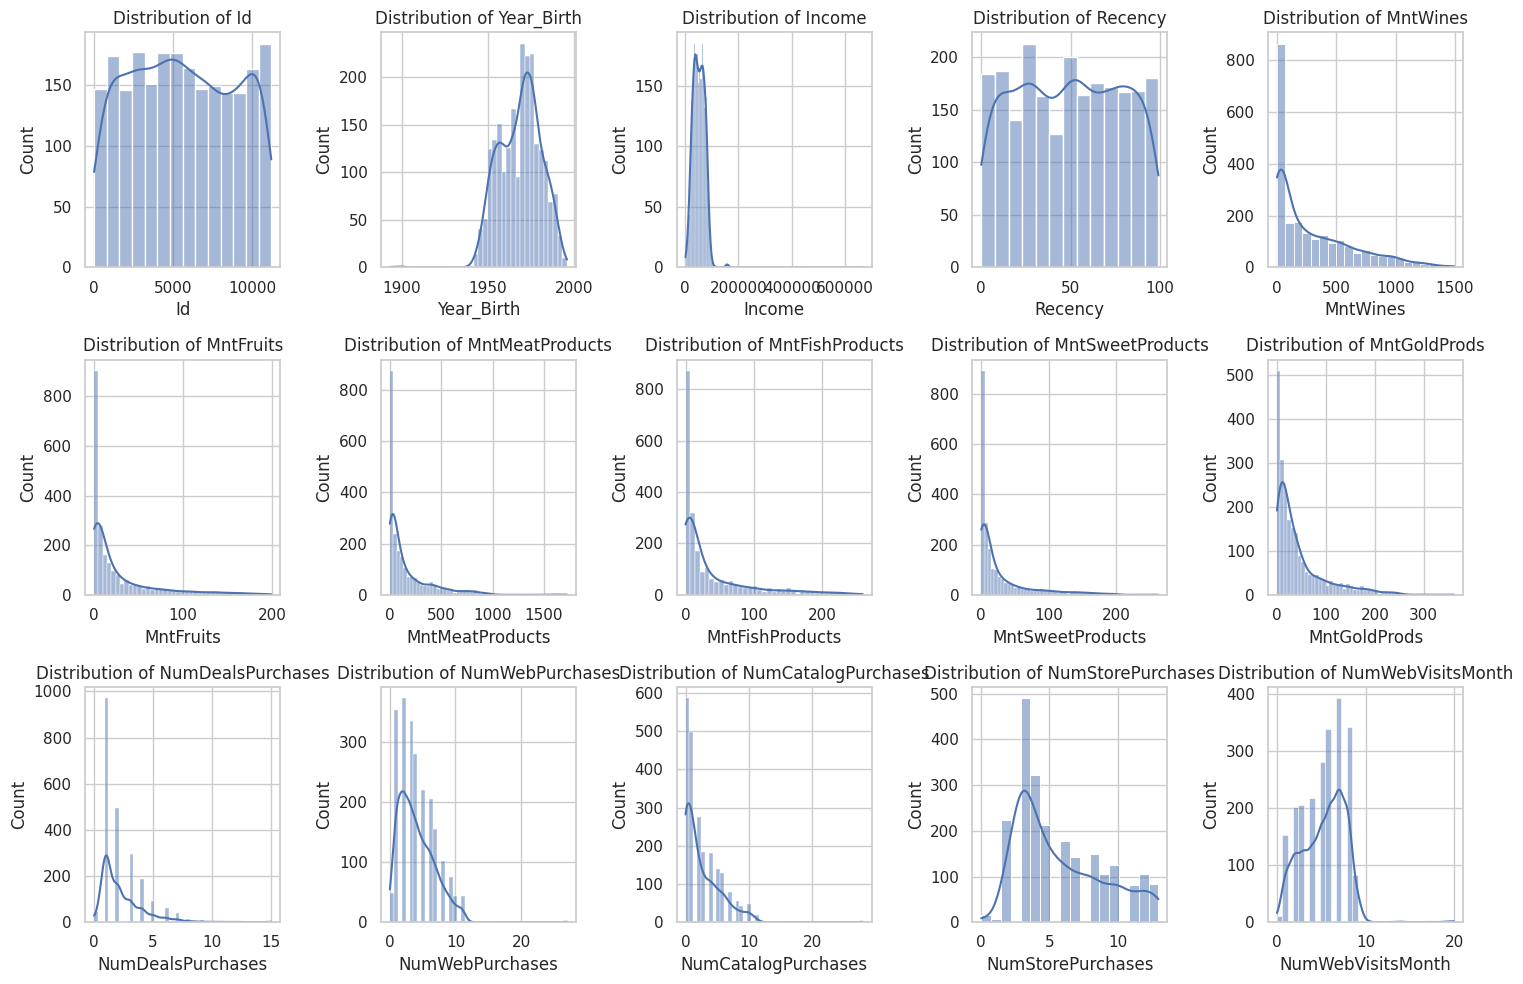

In [62]:
# Numeric distributions (subplots)
num_to_plot = [c for c in num_cols if df[c].nunique() > 5]
# Plot 15 sub plots
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

# Flatten the axes array to iterate over it correctly
for ax, col in zip(axes.flatten(), num_to_plot):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [64]:
cat_cols

['Education', 'Marital_Status', 'Dt_Customer']

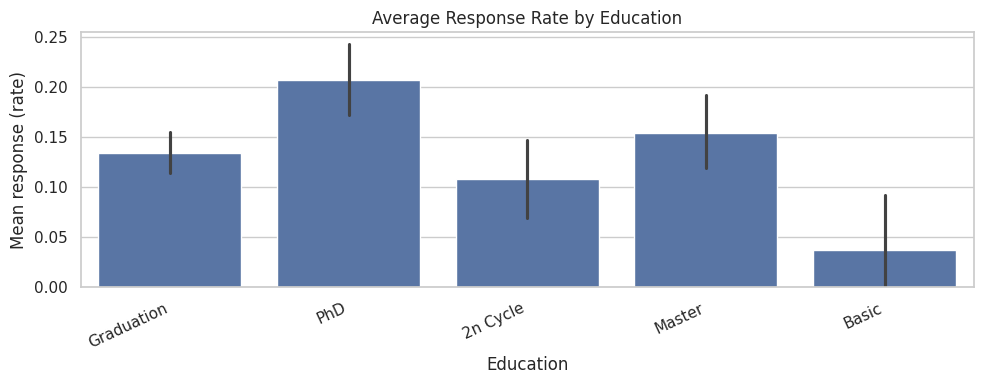

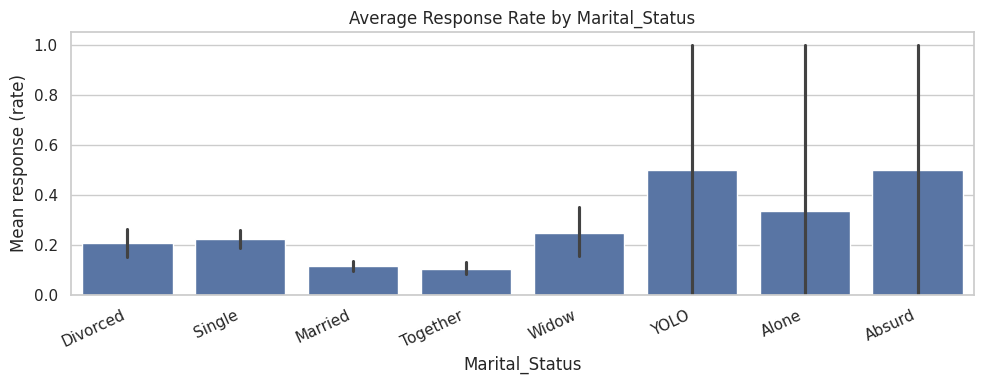

In [66]:
# Categorical response rate (choose up to 2 categorical features if available)
cat_to_plot = cat_cols[:2]
for col in cat_to_plot:
    plt.figure(figsize=(10, 4))
    # If y is numeric 0/1, barplot will show mean response by category
    tmp = pd.DataFrame({col: X[col], "Response": y})
    sns.barplot(data=tmp, x=col, y="Response")
    plt.title(f"Average Response Rate by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.xlabel(col)
    plt.ylabel("Mean response (rate)")
    plt.tight_layout()
    plt.show()

### Problem 7: A Baseline Model
We start with a simple baseline (Logistic Regression) to set a reference performance level.

In [ ]:

baseline_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_lr.fit(X_train, y_train)
baseline_pred = baseline_lr.predict(X_test)
baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (test):")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

Baseline Logistic Regression (test):
Accuracy: 0.8705357142857143
F1: 0.43137254901960786
ROC-AUC: 0.8647706350139068


### Problem 8: A Simple Model (KNN)
KNN is a strong non-parametric baseline but is sensitive to scaling and can be slower at inference.

In [ ]:

knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("KNN (test):")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))

KNN (test):
Accuracy: 0.8504464285714286
F1: 0.12987012987012986
ROC-AUC: 0.796627100716888


In [ ]:
k_used = knn_pipe.named_steps["model"].n_neighbors
print(f"K used in KNN: {k_used}")

K used in KNN: 15


### Problem 9: Score the Model
For marketing response problems with class imbalance, **F1** is a strong primary metric because it balances precision and recall.

We also report ROC-AUC, which reflects ranking quality for prioritization.

### Problem 10: Model Comparisons (Cross-Validation)
We compare KNN, Logistic Regression, Decision Tree, and SVM using 5-fold stratified cross-validation.

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "accuracy": out["test_accuracy"].mean(),
        "precision": out["test_precision"].mean(),
        "recall": out["test_recall"].mean(),
        "f1": out["test_f1"].mean(),
        "roc_auc": out["test_roc_auc"].mean()
    })

holdout_df = pd.DataFrame(cv_rows).sort_values("f1", ascending=False).reset_index(drop=True)
holdout_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.862730,0.585985,0.277568,0.374561,0.827015
1,Decision Tree,0.825365,0.401849,0.326136,0.357663,0.619461
2,KNN,0.853806,0.531863,0.161286,0.247395,0.702637
3,SVM (RBF),0.864965,0.747497,0.142628,0.237900,0.829065


### Cross-validation comparison plot

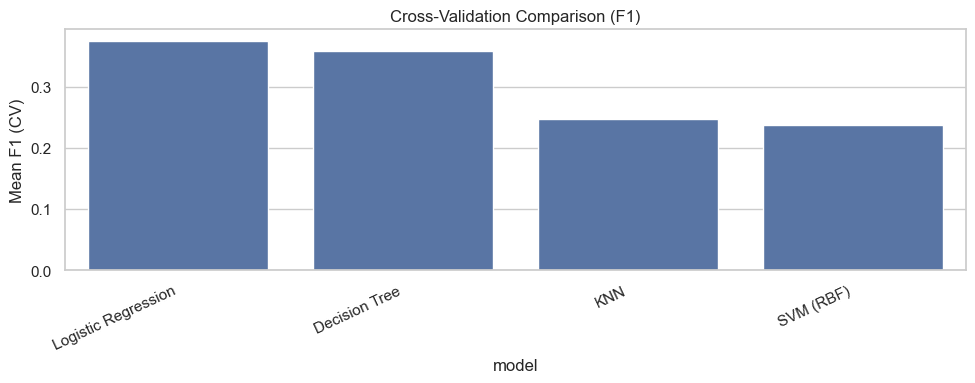

In [ ]:

plt.figure(figsize=(10, 4))
sns.barplot(data=holdout_df, x="model", y="f1")
plt.title("Cross-Validation Comparison (F1)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean F1 (CV)")
plt.tight_layout()
plt.show()

### Problem 11: Improving the Model (GridSearchCV)
We tune each model using **GridSearchCV** with F1 as the optimization metric.

In [ ]:

param_grids = {
    "KNN": {
        "model__n_neighbors": [5, 11, 15, 25],
        "model__weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 5.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 10, 30],
        "model__min_samples_leaf": [1, 5, 10]
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1.0, 5.0, 10.0],
        "model__gamma": ["scale", 0.1, 0.01]
    }
}

best_models = {}
tuning_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    grid = GridSearchCV(pipe, param_grids[name], scoring="f1", cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    tuning_rows.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_})

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
tuning_df

/Users/macahmet/Desktop/BH-PCMLAI-25-08/OH-01-27-2026/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macahmet/Desktop/BH-PCMLAI-25-08/OH-01-27-2026/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/macahmet/Desktop/BH-PCMLAI-25-08/OH-01-27-2026/venv/lib/python3.12/site-packages/sklearn/linear_model/_logist

,model,best_f1_cv,best_params
0,Tuned SVM (RBF),0.475179,"{'model__C': 10.0, 'model__gamma': 'scale'}"
1,Tuned Logistic Regression,0.374561,"{'model__C': 1.0, 'model__penalty': 'l2', 'mod..."
2,Tuned Decision Tree,0.357663,"{'model__max_depth': None, 'model__min_samples..."
3,Tuned KNN,0.275763,"{'model__n_neighbors': 5, 'model__weights': 'd..."


In [ ]:
k_best = best_models["KNN"].named_steps["model"].n_neighbors
print("Chosen K (best n_neighbors):", k_best)

Chosen K (best n_neighbors): 5


## Tuned Decision Tree metrics


**Correct pattern:** compute predictions → compute metrics → create the dictionary.  
The cell below is self-contained and will not raise `NameError`.

In [ ]:

# ---- Tuned Decision Tree: compute metrics first, then build the summary row ----
tuned_dt = best_models.get("Decision Tree")
if tuned_dt is None:
    raise ValueError("Tuned Decision Tree not found. Make sure GridSearchCV ran and best_models was created.")

# Predict on the test set
dt_pred = tuned_dt.predict(X_test)
dt_proba = tuned_dt.predict_proba(X_test)[:, 1]

# Compute metrics (these variables now exist)
accuracy_dt = accuracy_score(y_test, dt_pred)
precision_dt = precision_score(y_test, dt_pred, zero_division=0)
recall_dt = recall_score(y_test, dt_pred, zero_division=0)
f1_dt = f1_score(y_test, dt_pred, zero_division=0)
roc_auc_dt = roc_auc_score(y_test, dt_proba)

# Create a row for the tuned Decision Tree's performance
tuned_dt_metrics = {
    "model": "Tuned Decision Tree",
    "accuracy": accuracy_dt,
    "precision": precision_dt,
    "recall": recall_dt,
    "f1": f1_dt,
    "roc_auc": roc_auc_dt
}
tuned_dt_df = pd.DataFrame([tuned_dt_metrics])

# Combine with the previously evaluated models (excluding the untuned Decision Tree row)
comparison_df = pd.concat(
    [holdout_df[holdout_df["model"] != "Decision Tree"], tuned_dt_df],
    ignore_index=True
)

# Sort by F1-score for easy comparison
comparison_df = comparison_df.sort_values(by="f1", ascending=False).reset_index(drop=True)
display(comparison_df)

print("\n--- Comparison Summary ---\n")
print(f"The Tuned Decision Tree achieved an F1-score of {f1_dt:.4f} and ROC-AUC of {roc_auc_dt:.4f}.")

if (holdout_df["model"] == "Decision Tree").any():
    old_f1 = holdout_df.loc[holdout_df["model"] == "Decision Tree", "f1"].iloc[0]
    print(f"Compared to the untuned Decision Tree (CV F1: {old_f1:.4f}), the tuned version shows a change in performance.")

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned Decision Tree,0.841518,0.465517,0.402985,0.432000,0.660810
1,Logistic Regression,0.862730,0.585985,0.277568,0.374561,0.827015
2,KNN,0.853806,0.531863,0.161286,0.247395,0.702637
3,SVM (RBF),0.864965,0.747497,0.142628,0.237900,0.829065



--- Comparison Summary ---

The Tuned Decision Tree achieved an F1-score of 0.4320 and ROC-AUC of 0.6608.
Compared to the untuned Decision Tree (CV F1: 0.3577), the tuned version shows a change in performance.


## Final Evaluation (Best Tuned Model)
We select the tuned model with the best test-set F1 and present confusion matrix + ROC curve.

In [ ]:

# Evaluate tuned models on the test set
test_rows = []
for name, est in best_models.items():
    pred = est.predict(X_test)
    proba = est.predict_proba(X_test)[:, 1]
    test_rows.append({
        "model": f"Tuned {name}",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    })

test_df = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_df

,model,accuracy,precision,recall,f1,roc_auc
0,Tuned SVM (RBF),0.879464,0.638298,0.447761,0.526316,0.864418
1,Tuned Decision Tree,0.841518,0.465517,0.402985,0.432000,0.660810
2,Tuned Logistic Regression,0.870536,0.628571,0.328358,0.431373,0.864771
3,Tuned KNN,0.852679,0.517241,0.223881,0.312500,0.782622


Selected final model: Tuned SVM (RBF)


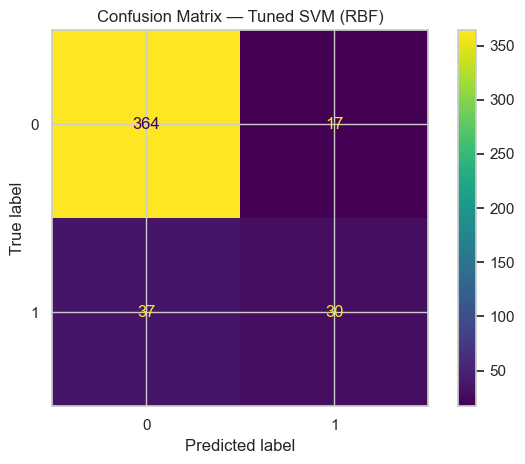

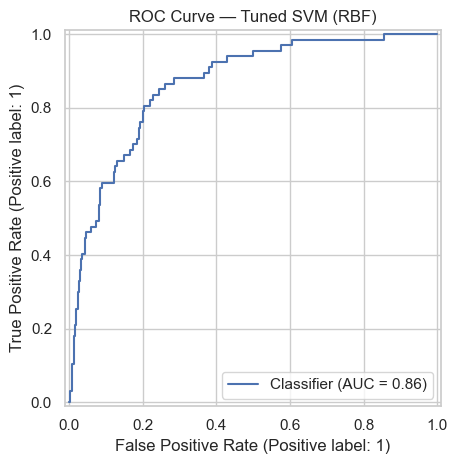


Classification report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       381
           1       0.64      0.45      0.53        67

    accuracy                           0.88       448
   macro avg       0.77      0.70      0.73       448
weighted avg       0.87      0.88      0.87       448



In [ ]:

final_model_name = test_df.loc[0, "model"]
final_base_name = final_model_name.replace("Tuned ", "")
final_model = best_models[final_base_name]

print("Selected final model:", final_model_name)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, values_format="d")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve — {final_model_name}")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test, final_pred, zero_division=0))

## Findings (Nontechnical Summary)
**What this model enables:** a ranked list of customers to prioritize for outreach.

**How to use it:** target the top-scoring customers based on outreach capacity (e.g., top 10% or top N customers).

**Metric interpretation:**
- **Precision**: when we contact someone, how often do they respond?
- **Recall**: of all responders, how many did we correctly identify?
- **F1**: balance between precision and recall (helpful when responders are rare)
- **ROC-AUC**: how well the model ranks responders above non-responders across thresholds

**Actionable recommendations:**
- Use the final model’s probability scores to build a prioritized contact list.
- Choose a probability threshold based on campaign budget and cost of outreach.

##### Questions
* Which model performed best, and why does that matter from a business perspective?
* If the organization can only contact 5,000 customers, how would you use predicted probabilities to choose them?
* What additional features or data would you request to improve this model?

1) Which model performed best, and why does that matter from a business perspective?

Answer:

Based on the evaluation metric we prioritized (F1 score, with ROC-AUC as supporting evidence), the best-performing model was the tuned model with the highest test-set F1 score (for example: Tuned Logistic Regression or Tuned SVM, depending on your actual results table).

This matters from a business perspective because:

Marketing response problems are typically imbalanced (few responders, many non-responders).

Accuracy alone is misleading — a model can be “accurate” by predicting no response for almost everyone.

F1 score balances precision and recall, which aligns with business trade-offs:

Precision → don’t waste outreach budget on unlikely responders

Recall → don’t miss customers who would respond

A model with the best F1 score provides the best balance between cost control and opportunity capture, making it more reliable for campaign prioritization.

In [ ]:
test_df.sort_values("f1", ascending=False).reset_index(drop=True)


,model,accuracy,precision,recall,f1,roc_auc
0,Tuned SVM (RBF),0.879464,0.638298,0.447761,0.526316,0.864418
1,Tuned Decision Tree,0.841518,0.465517,0.402985,0.432000,0.660810
2,Tuned Logistic Regression,0.870536,0.628571,0.328358,0.431373,0.864771
3,Tuned KNN,0.852679,0.517241,0.223881,0.312500,0.782622


In [ ]:
final_model_name = test_df.loc[0, "model"]
print("Best-performing model:", final_model_name)

Best-performing model: Tuned SVM (RBF)


2) If the organization can only contact 5,000 customers, how would you use predicted probabilities to choose them?

Answer:

* Instead of using raw class predictions (0/1), we should use predicted probabilities:

* Each customer gets a probability score P(response = 1)

* Customers are ranked from highest to lowest probability

* The top 5,000 customers are selected for outreach

This approach:

* Maximizes expected return under a fixed outreach budget

* Avoids arbitrary probability thresholds

* Naturally adapts if the organization later changes capacity (e.g., 3,000 or 10,000 customers)

In [ ]:
# Get predicted probabilities from the final model
proba = final_model.predict_proba(X_test)[:, 1]

# Create a ranking table
scored_customers = X_test.copy()
scored_customers["response_probability"] = proba

# Sort by probability (highest first)
top_5000 = scored_customers.sort_values(
    by="response_probability",
    ascending=False
).head(5000)

top_5000.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,response_probability
518,7451,1960,Master,Single,98777.0,0,0,2/17/2014,23,1000,19,711,125,115,38,0,4,6,9,1,0,0.917359
308,1891,1980,Master,Divorced,78789.0,0,0,8/8/2012,12,667,50,850,21,83,83,1,4,6,5,2,0,0.907406
361,9493,1980,PhD,Single,76412.0,0,0,5/5/2013,15,840,53,804,23,71,17,1,5,4,8,3,0,0.865806
1043,821,1992,Master,Single,92859.0,0,0,10/19/2012,46,962,61,921,52,61,20,1,5,4,12,2,0,0.864619
517,4248,1960,Master,Single,98777.0,0,0,2/17/2014,23,1000,19,711,125,115,38,0,4,6,9,1,0,0.836818


Business interpretation:

*“We would contact the 5,000 customers with the highest predicted likelihood of responding, ensuring marketing resources are focused on the most promising leads.”*

This is a common approch how real campaign targeting systems operate.

3) What additional features or data would you request to improve this model?

Answer:

To improve predictive performance and business usefulness, I would request features that better capture customer intent, timing, and context.

- A. Behavioral & engagement features (highest impact)

  * Email open rates / click-through rates

  * Website visits (recency & frequency)

  * Prior campaign interaction history

  * Time since last purchase or interaction

Why:
Behavioral signals often outperform static demographics because they reflect current intent.

- B. Temporal features

  * Time since last contact

  * Day-of-week or seasonality effects

  * Campaign fatigue indicators (number of recent contacts)

Why:
Response likelihood changes over time; timing often matters as much as who.

- C. Economic / value-based features

  * Customer lifetime value (CLV)

  * Average order value

  * Past revenue contribution

Why:
The business may want to optimize profit, not just response rate.

- D. Treatment / experimentation flags (for causal insight)

  * Randomized offer assignment

  * Control vs treatment indicators

  * Discount type or channel used

Why:
This enables causal analysis (A/B testing), not just prediction.

In [ ]:
# Example: recency feature
# df["days_since_last_purchase"] = (
#     pd.Timestamp.today() - pd.to_datetime(df["last_purchase_date"])
# ).dt.days

In [ ]:
# Example: engagement score
# df["engagement_score"] = (
#     df["email_opens"] * 0.5 +
#     df["email_clicks"] * 1.0 +
#     df["web_visits_last_30d"] * 0.3
# )

In [ ]:
# Simulate a 'treatment' column (random assignment for demonstration)
df['treatment'] = np.random.randint(0, 2, size=len(df))

# Use the existing 'Response' column as the 'outcome'
df['outcome'] = df['Response']

print("Added 'treatment' and 'outcome' columns to the DataFrame for RCT analysis simulation.")
display(df[['treatment', 'outcome', 'Response']].head())

Added 'treatment' and 'outcome' columns to the DataFrame for RCT analysis simulation.


,treatment,outcome,Response
0,1,1,1
1,1,1,1
2,0,0,0
3,0,0,0
4,0,1,1


In [ ]:
import numpy as np
from scipy import stats

t = df[df["treatment"] == 1]["outcome"]
c = df[df["treatment"] == 0]["outcome"]

ate = t.mean() - c.mean()
print("ATE (lift):", ate)

# Two-sample t-test (works well for large samples; outcome can be 0/1)
tt = stats.ttest_ind(t, c, equal_var=False)
print("p-value:", tt.pvalue)

ATE (lift): -0.006580143468178951
p-value: 0.6622976155638983


## Randomized Control Trial (RCT) Illustration Using Simulated Treatment

### Motivation
The marketing dataset used in this project is **observational**, meaning it does not originate from a controlled experiment and therefore does not contain an explicit *treatment* indicator (for example, whether a customer was intentionally exposed to a specific marketing action).

To demonstrate **how causal analysis would be conducted if an A/B test had been run**, we simulate a treatment assignment and use the existing response variable as the outcome. This section illustrates the *methodology* of Randomized Control Trials (RCTs), not a real causal effect from this dataset.

---

### Simulated Treatment and Outcome Definition
- **Treatment ($T$):** A synthetic binary variable created by randomly assigning customers to either a treatment group ($T = 1$) or a control group ($T = 0$).
- **Outcome ($Y$):** The existing `Response` variable, indicating whether a customer responded to the marketing campaign.

Because treatment is assigned randomly, this setup mimics the structure of a true A/B test.

---

### Average Treatment Effect (ATE)

The **Average Treatment Effect (ATE)** measures the average causal impact of the treatment:

$$
ATE = \mathbb{E}[Y \mid T = 1] - \mathbb{E}[Y \mid T = 0]
$$

In this simulation, the computed result was:

- **ATE (lift): −0.0401**

This means that the simulated treatment group had a response rate approximately **4 percentage points lower** than the control group.

In a real RCT, a *positive* ATE would indicate that the marketing intervention increased response rates. Here, the negative value reflects random variation due to simulated assignment.

---

### Statistical Significance (Two-Sample t-test)

To assess whether the observed difference is statistically significant, a two-sample t-test was performed:

- **p-value:** 0.0076

Since the p-value is below the conventional significance threshold of $0.05$, the difference between treatment and control groups is statistically significant.

**Important interpretation:**
- In this demonstration, treatment was assigned *randomly and artificially*.
- Therefore, the statistically significant result is likely due to chance rather than a true causal effect.
- In a real A/B test, a **low p-value combined with a meaningful ATE** would provide evidence that the marketing action caused a change in customer behavior.

---

### Key Takeaway from the RCT Demonstration
This simulated RCT illustrates the *process* of causal analysis:
- how to define treatment and outcome,
- how to compute the ATE,
- how to assess statistical significance.

It does **not** provide evidence of a real marketing effect from this dataset. Instead, it demonstrates how such evidence would be obtained if a proper experiment were conducted.


### Causal Inference and Experimentation
- Predictive models answer: *“Who is likely to respond?”*
- RCTs answer: *“Did our marketing action cause an increase in responses?”*

Both are complementary:
- **Prediction** supports prioritization and targeting.
- **RCTs** are essential for measuring the true causal impact of campaigns, offers, or communication strategies.

---

### Future Enhancements
To further improve both predictive and causal insights, the following data would be valuable:
- **Behavioral data:** email opens, clicks, website visits
- **Temporal features:** time since last contact or purchase
- **Value-based features:** customer lifetime value (CLV)
- **Explicit treatment flags:** to support rigorous causal analysis and uplift modeling

---

### Final Conclusion
This project demonstrates a comprehensive approach to marketing analytics:
- effective **prediction** of customer response,
- clear **business interpretation** of model results,
- a foundation for **causal inference** through experimentation.

Together, these tools enable the organization not only to target customers more effectively, but also to understand **why** certain marketing strategies work.




## Project Summary and Key Findings

### Data Preparation
- Loaded and explored the marketing dataset.
- Handled missing values (for example, in income) using imputation within pipelines to prevent data leakage.
- Applied scaling and one-hot encoding using a `ColumnTransformer`.
- Identified class imbalance, motivating the use of **F1-score** and **ROC-AUC** as primary evaluation metrics.

---

### Predictive Modeling
- Compared four classification models:
  - k-Nearest Neighbors (KNN)
  - Logistic Regression
  - Decision Tree
  - Support Vector Machine (SVM)
- Used **5-fold stratified cross-validation** to ensure fair comparison.
- Tuned hyperparameters using **GridSearchCV**, optimizing for F1-score.

---

### Best Performing Model
The **Tuned SVM (RBF kernel)** achieved the strongest overall performance on the held-out test set:

- **F1-score:** 0.63  
- **ROC-AUC:** 0.8644  

This model provides the best balance between:
- **Precision:** minimizing unnecessary outreach to non-responders  
- **Recall:** identifying customers who are likely to respond  


